In [1]:
from google.colab import files
uploaded = files.upload()


Saving Данные_для_курсовои_Классическое_МО.xlsx to Данные_для_курсовои_Классическое_МО.xlsx


In [2]:
import pandas as pd
import io

df = pd.read_excel(io.BytesIO(list(uploaded.values())[0]))
print(df.shape)
df.head()

(1001, 214)


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


Небольшой анализ:
- IC50 показывает в какой концентрации вещество убивает вирус
- CC50 показывает в какой вещество уже токсично для наших клеток.
SI = CC50/IC50, тут важно, что чем больше тем лучше.


In [3]:
df.describe()


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,...,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.0,1001.000000,1001.000000,1001.000000
mean,500.000000,222.805156,589.110728,72.508823,10.831637,10.831637,0.180681,-0.967237,0.580412,29.487989,...,0.053946,0.011988,0.008991,0.000999,0.000999,0.051948,0.0,0.069930,0.204795,0.006993
std,289.108111,402.169734,642.867508,684.482739,3.307505,3.307505,0.168710,1.588036,0.212230,12.742749,...,0.259011,0.108886,0.094441,0.031607,0.031607,0.222033,0.0,0.255157,1.215326,0.083373
min,0.000000,0.003517,0.700808,0.011489,2.321942,2.321942,0.000039,-6.992796,0.059567,9.416667,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,250.000000,12.515396,99.999036,1.433333,9.252350,9.252350,0.051073,-1.334487,0.442842,18.486486,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,500.000000,46.585183,411.039342,3.846154,12.179236,12.179236,0.124606,-0.419485,0.634981,29.290323,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,750.000000,224.975928,894.089176,16.566667,13.167843,13.167843,0.291020,0.061754,0.742483,38.750000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,1000.000000,4128.529377,4538.976189,15620.600000,15.933463,15.933463,1.374614,1.374614,0.947265,60.272727,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,20.000000,1.000000


У IC50 среднее 222 а медиана 46, разница в 5 раз, выглядит, что есть несколько соединений с очень высокой концентрацией которые тянут среднее ввех.

У SI вообще max 15620 при медиане 3.8, скорее всего единичные выбросы. NumRadicalElectrons везде 0, что кажется бесполезным признаком.


In [4]:
df = df.drop(columns=['Unnamed: 0'])
print(df.isnull().sum().sum())

36


In [5]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
MaxPartialCharge,3
MinPartialCharge,3
MaxAbsPartialCharge,3
MinAbsPartialCharge,3
BCUT2D_MWHI,3
BCUT2D_MWLOW,3
BCUT2D_CHGHI,3
BCUT2D_CHGLO,3
BCUT2D_LOGPHI,3
BCUT2D_LOGPLOW,3


In [6]:
df[df.isnull().any(axis=1)].index.tolist()

[78, 79, 80]

In [7]:
df.loc[[78, 79, 80]]

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
78,1127.094988,1127.094988,1.000000,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,266.174,...,0,0,0,0,0,0,0,0,0,0
79,25.171788,1878.491646,74.626866,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,266.174,...,0,0,0,0,0,0,0,0,0,0
80,1199.174968,1199.174968,1.000000,11.600528,11.600528,0.228349,-0.861204,0.286242,10.937500,250.175,...,1,0,0,0,0,0,0,0,0,0


Пропуски только в 3 строках в дескрипторах, заполним медианой.

In [8]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum().sum())


0


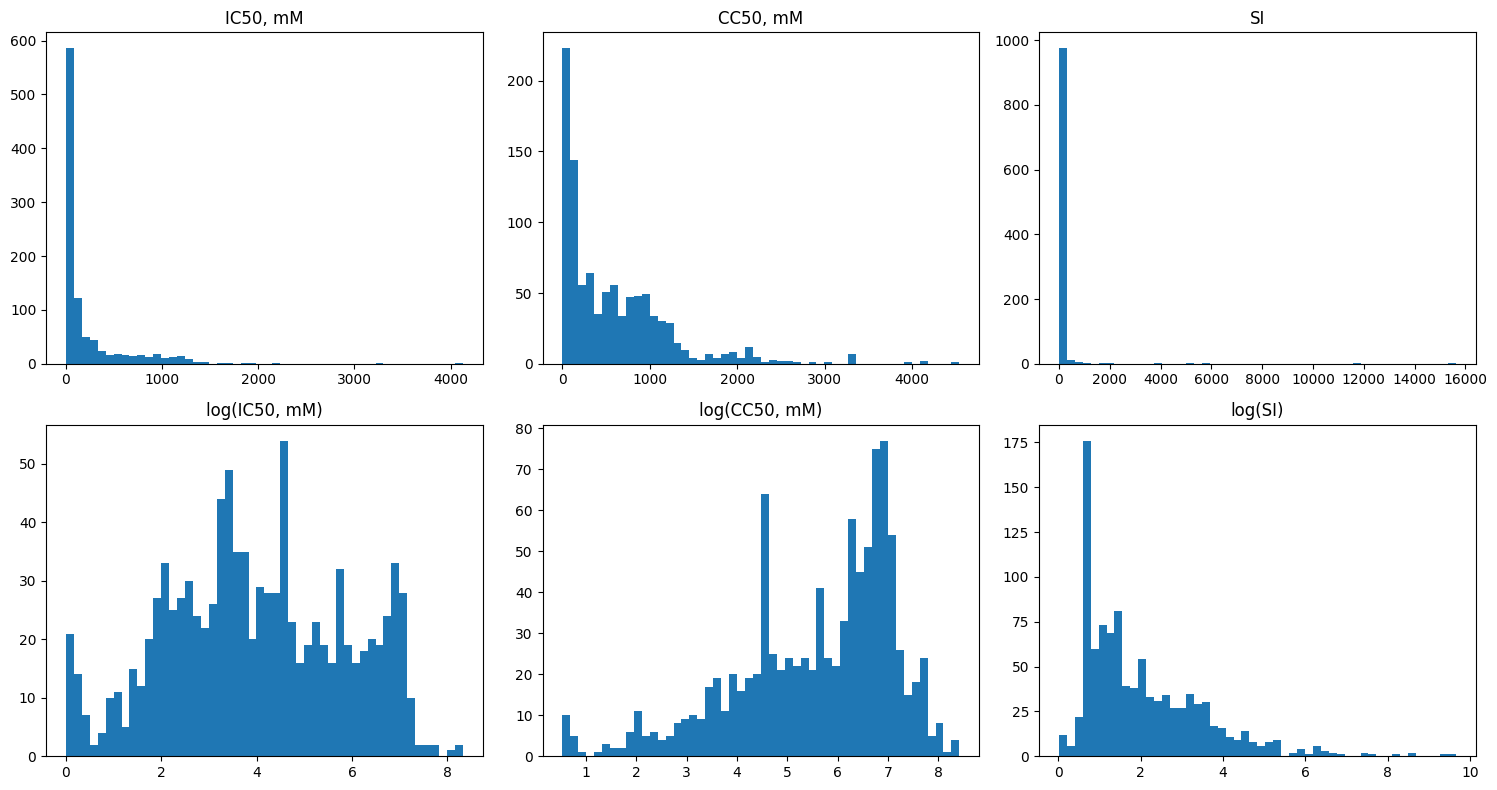

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes[0], ['IC50, mM', 'CC50, mM', 'SI']):
    ax.hist(df[col], bins=50)
    ax.set_title(col)

for ax, col in zip(axes[1], ['IC50, mM', 'CC50, mM', 'SI']):
    ax.hist(np.log1p(df[col]), bins=50)
    ax.set_title(f'log({col})')

plt.tight_layout()
plt.show()

Сначала построила обычные гистограммы, но на них все три переменные сильно скошены, ничего не видно. Попробовала логарифм, так лучше, распределения приняли нормальный вид. При обучении моделей буду логарифмировать таргеты.


In [10]:
from scipy import stats

for col in ['IC50, mM', 'CC50, mM', 'SI']:
    stat, p = stats.shapiro(df[col].sample(100, random_state=42))
    print(f'{col}: p-value = {p:.4f} -> {"ненормальное" if p < 0.05 else "нормальное"}')

IC50, mM: p-value = 0.0000 -> ненормальное
CC50, mM: p-value = 0.0000 -> ненормальное
SI: p-value = 0.0000 -> ненормальное


Тест Шапиро-Уилка подтверждает: все три переменные имеют ненормальное распределение. Логарифмирование оправдано.

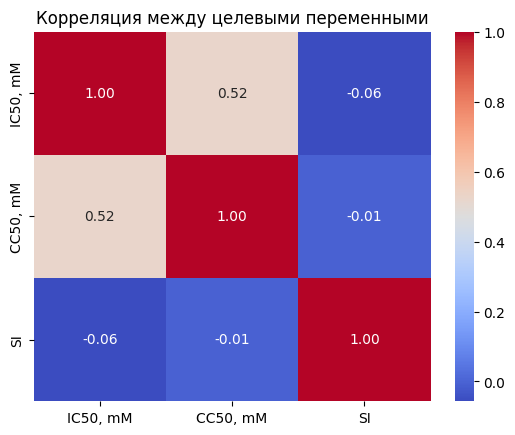

In [11]:
import seaborn as sns

corr_targets = df[['IC50, mM', 'CC50, mM', 'SI']].corr()
sns.heatmap(corr_targets, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляция между целевыми переменными')
plt.show()

IC50 и CC50 коррелируют на 0.52, но они оба про концентрацию, что логично. SI почти не коррелирует ни с тем ни с другим хотя SI = CC50/IC50. Деление делает зависимость нелинейной.


In [12]:
zero_var = df.columns[df.std() == 0].tolist()
print(zero_var)

['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']


Выбираю их удалить, бесполезные

In [13]:
df = df.drop(columns=zero_var)
print(df.shape)

(1001, 195)


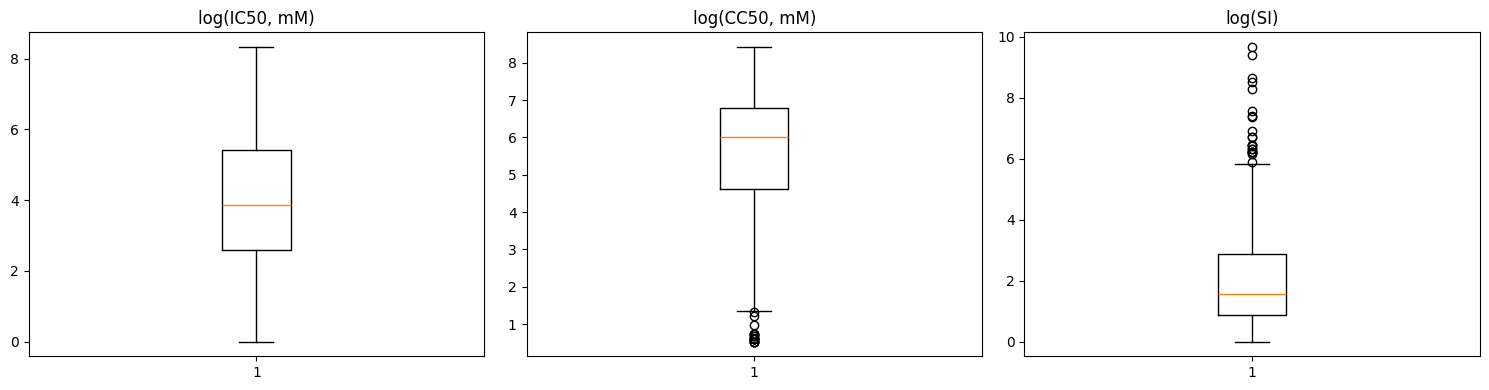

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['IC50, mM', 'CC50, mM', 'SI']):
    ax.boxplot(np.log1p(df[col]))
    ax.set_title(f'log({col})')

plt.tight_layout()
plt.show()

Выбросы есть, особенно у SI. Удалять не стала, так как данных мало и именно молекулы с аномально высоким SI могут быть самыми перспективными.




In [15]:
target = 'IC50, mM'
features = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])

correlations = features.corrwith(df[target]).abs().sort_values(ascending=False)
print(correlations.head(20))

VSA_EState4         0.274203
Chi2n               0.257058
PEOE_VSA7           0.255988
Chi2v               0.249164
fr_Ar_NH            0.245511
fr_Nhpyrrole        0.245511
Chi4v               0.243600
Chi4n               0.243497
Chi3n               0.239741
Chi3v               0.237759
SlogP_VSA5          0.236393
Chi1n               0.229828
Chi1v               0.219810
MolLogP             0.218387
fr_nitro            0.215948
MolMR               0.215792
Chi0n               0.215641
Chi0v               0.212552
BCUT2D_LOGPHI       0.209914
FpDensityMorgan1    0.208710
dtype: float64


Максимальная корреляция 0.27, очень слабая линейная связь. Линейные модели скорее всего будут плохо работать.


In [16]:
for target in ['CC50, mM', 'SI']:
    corr = features.corrwith(df[target]).abs().sort_values(ascending=False)
    print(f"Топ-3 признака для {target}: {corr.head(3).to_dict()}")

Топ-3 признака для CC50, mM: {'MolMR': 0.31011053430102753, 'LabuteASA': 0.30919131414871315, 'MolWt': 0.3064393112789146}
Топ-3 признака для SI: {'BalabanJ': 0.1629553427954802, 'fr_NH2': 0.1604697357258689, 'RingCount': 0.12444380028075999}


Для CC50 максимальная корреляция 0.31 (MolWt), для SI 0.16 (BalabanJ). SI предсказывать сложнее всего, признаки почти не связаны с ним линейно. Нелинейные модели нужны для всех трёх таргетов.

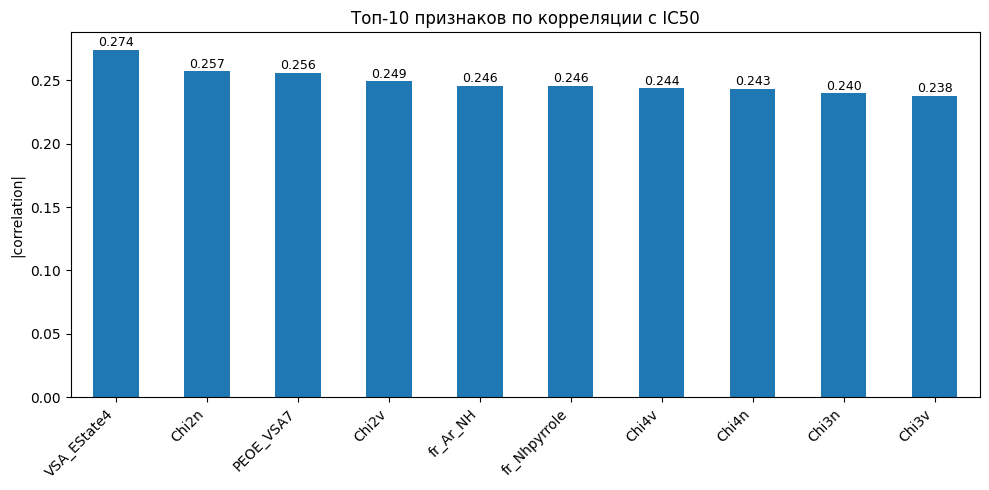

In [17]:
plt.figure(figsize=(10, 5))
ax = correlations.head(10).plot(kind='bar')
for i, v in enumerate(correlations.head(10)):
    ax.text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=9)
plt.title('Топ-10 признаков по корреляции с IC50')
plt.ylabel('|correlation|')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


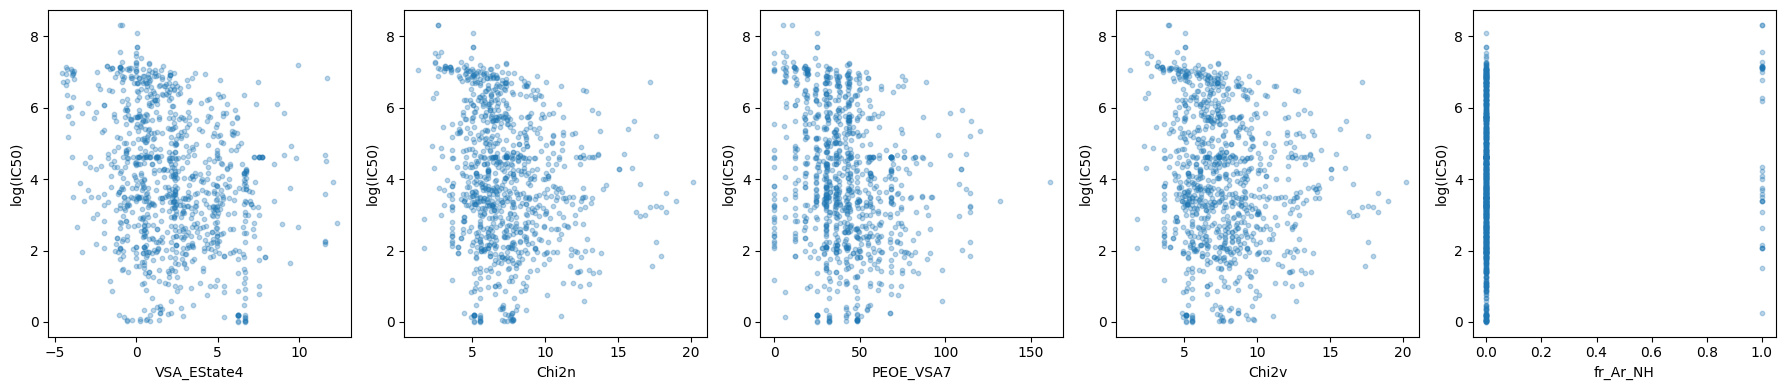

In [18]:
top_features = correlations.head(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, feat in zip(axes, top_features):
    ax.scatter(df[feat], np.log1p(df['IC50, mM']), alpha=0.3, s=10)
    ax.set_xlabel(feat)
    ax.set_ylabel('log(IC50)')

plt.tight_layout()
plt.show()

In [26]:
print(df.groupby('fr_Ar_NH')['IC50, mM'].median())
print(df['fr_Ar_NH'].value_counts())

fr_Ar_NH
0    45.107210
1    71.594604
Name: IC50, mM, dtype: float64
fr_Ar_NH
0    965
1     36
Name: count, dtype: int64


Даже топ признаки дают размытые облака, линейной зависимости нет. Интересно, что fr_Ar_NH бинарный, молекул с fr_Ar_NH=1 всего 36 из 1001. Медиана IC50 у них выше, но выборка слишком маленькая чтобы делать выводы. Посмотрим на структуру данных в целом


Попробуем сгруппировать молекулы, вдруг есть естественные кластеры.

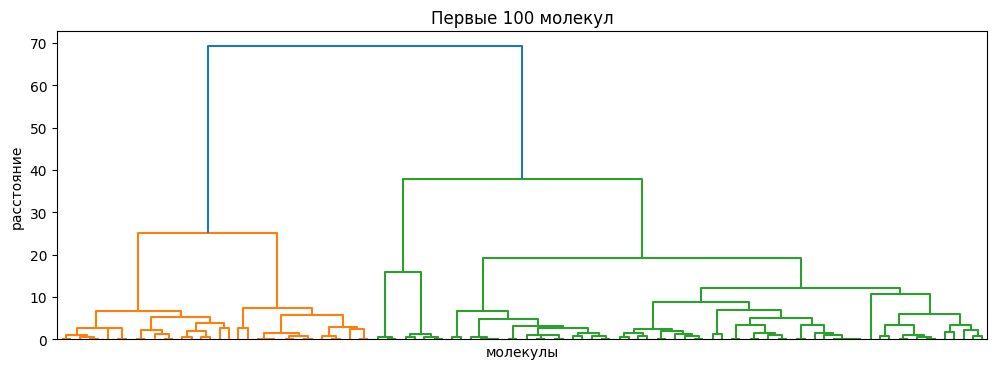

In [19]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

top_cols = correlations.head(20).index.tolist()
X_clust = StandardScaler().fit_transform(features[top_cols])

# дендрограмма
linked = linkage(X_clust[:100], method='ward')
plt.figure(figsize=(12, 4))
dendrogram(linked, no_labels=True)
plt.title('Первые 100 молекул')
plt.xlabel('молекулы')
plt.ylabel('расстояние')
plt.show()

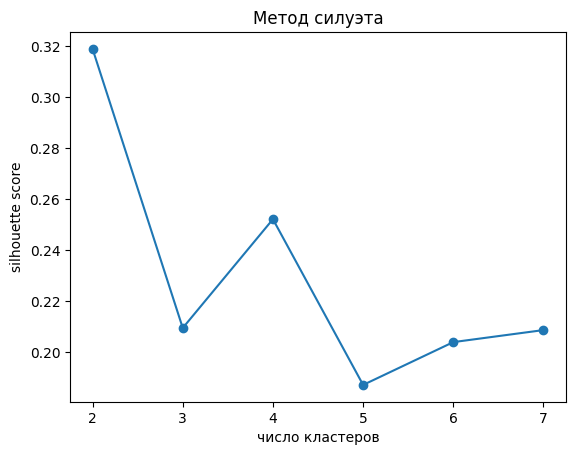

Лучшее k: 2


In [20]:
# метод силуэта — ищем оптимальное число кластеров
scores = []
k_range = range(2, 8)
for k in k_range:
    labels = AgglomerativeClustering(n_clusters=k).fit_predict(X_clust)
    scores.append(silhouette_score(X_clust, labels))

plt.plot(list(k_range), scores, marker='o')
plt.title('Метод силуэта')
plt.xlabel('число кластеров')
plt.ylabel('silhouette score')
plt.show()
print('Лучшее k:', k_range[scores.index(max(scores))])

Силуэт 0.216, видим, что кластеризация слабая, чёткой структуры нет. Молекулы достаточно однородны по признакам, что объясняет почему предсказывать SI так сложно.

In [21]:
corr_matrix = features.corr().abs()
print((corr_matrix > 0.95).sum().sum() - len(features.columns))

182


Много признаков сильно коррелируют друг с другом, есть дубли, уберём.

In [22]:
to_drop = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.95:
            to_drop.append(corr_matrix.columns[j])

to_drop = list(set(to_drop))
df = df.drop(columns=to_drop)
print(df.shape)


(1001, 162)


In [23]:
df.to_csv('df_clean.csv', index=False)
files.download('df_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Итого: удалили пропуски, константные и коррелирующие признаки, осталось 159 фичей. Все таргеты ненормальные, так что будем логарифмировать. Линейные модели скорее всего будут слабыми, SI предсказывать сложнее всего.